# Fixed named regions in XDMF time series

Write point, cell and side regions once with the shared topology; every field step inherits them. Empty groups, names, dimensions and tags survive XML, Binary and HDF storage. The Python reader exposes `reader.regions` without changing its return tuples. Native writers take regions from the mesh and retain them through flush/append and raw-array steps. Time-varying membership is not part of this contract.

In [1]:
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import meshioplusplus as mio

points = np.array([[0., 0., 0.], [1., 0., 0.], [1., 1., 0.], [0., 1., 0.]])
cells = [('triangle', np.array([[0, 1, 2], [0, 2, 3]], dtype=np.int64))]
mesh = mio.Mesh(points, cells, regions=[
    mio.Region('anchors', 'point', [0, 3], dim=0, tag=7),
    mio.Region('solid', 'cell', [0, 1], dim=2, tag=21),
    mio.Region('boundary', 'side', [[0, 0], [1, 1]], dim=1, tag=9),
    mio.Region('empty selection', 'cell', [], dim=2, tag=22),
])
workspace = tempfile.TemporaryDirectory(prefix='mio_series_regions_')
path = Path(workspace.name) / 'regions.xdmf'

with mio.xdmf.TimeSeriesWriter(path, 'XML') as writer:
    writer.write_points_cells(mesh.points, mesh.cells, regions=mesh.regions)
    for t in (0., 0.5, 1.):
        writer.write_data(t, point_data={'temperature': points[:, 0] + t})

restored_steps = []
with mio.xdmf.TimeSeriesReader(path) as reader:
    restored_points, restored_cells = reader.read_points_cells()
    assert len(reader.regions) == 4
    for k in range(reader.num_steps):
        t, point_data, cell_data = reader.read_data(k)
        restored_steps.append((t, mio.Mesh(restored_points, restored_cells, point_data=point_data, cell_data=cell_data, regions=reader.regions)))
    for region in reader.regions:
        print(f'{region.name}: {region.kind}, dim={region.dim}, tag={region.tag}, entries={region.entries.tolist()}')


anchors: point, dim=0, tag=7, entries=[0, 3]
empty selection: cell, dim=2, tag=22, entries=[]
solid: cell, dim=2, tag=21, entries=[0, 1]
boundary: side, dim=1, tag=9, entries=[[0, 0], [1, 1]]


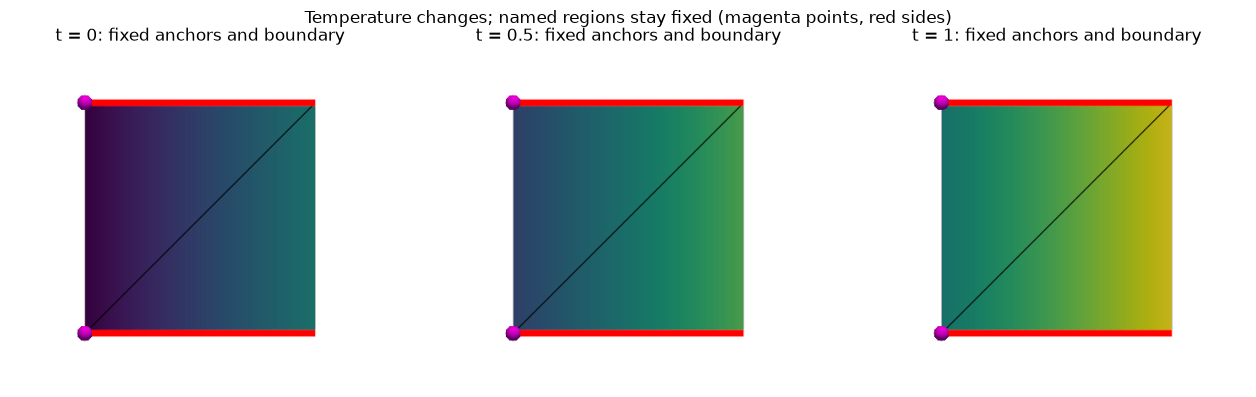

In [2]:
def render_step(ax, step, t):
    anchors = next(r for r in step.regions if r.name == 'anchors')
    boundary = next(r for r in step.regions if r.name == 'boundary')
    triangles = step.cells[0].data
    # Triangle local edges: (0,1), (1,2), (2,0).
    edge_nodes = np.array([[0, 1], [1, 2], [2, 0]])
    edges = [step.points[triangles[cell][edge_nodes[local]]] for cell, local in boundary.entries]
    try:
        import pyvista as pv
        pv.OFF_SCREEN = True
        grid = pv.PolyData(step.points, np.column_stack([np.full(len(triangles), 3), triangles]).ravel())
        grid['temperature'] = step.point_data['temperature']
        plotter = pv.Plotter(off_screen=True, window_size=(450, 400))
        plotter.add_mesh(grid, scalars='temperature', clim=(0, 2), cmap='viridis', show_edges=True, show_scalar_bar=False)
        plotter.add_points(step.points[anchors.entries], color='magenta', point_size=18, render_points_as_spheres=True)
        for edge in edges:
            plotter.add_lines(edge, color='red', width=8)
        plotter.view_xy()
        plotter.set_background('white')
        ax.imshow(plotter.screenshot())
        plotter.close()
        ax.axis('off')
    except Exception as exc:
        print(f'Using matplotlib fallback: {type(exc).__name__}')
        ax.tripcolor(step.points[:, 0], step.points[:, 1], triangles, step.point_data['temperature'], shading='gouraud', vmin=0, vmax=2, cmap='viridis')
        ax.triplot(step.points[:, 0], step.points[:, 1], triangles, color='black', lw=0.5)
        for edge in edges:
            ax.plot(edge[:, 0], edge[:, 1], color='red', lw=4)
        ax.scatter(*step.points[anchors.entries, :2].T, color='magenta', s=80, zorder=5)
        ax.set_aspect('equal')
    ax.set_title(f't = {t:g}: fixed anchors and boundary')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (t, step) in zip(axes, restored_steps):
    render_step(ax, step, t)
fig.suptitle('Temperature changes; named regions stay fixed (magenta points, red sides)')
fig.tight_layout()
plt.show()


## Native solver path: flush, append and selective reads

The same mesh-based call works in C++, C, Fortran, Julia, R and WASM. No new binding arguments are required. Here XML avoids an optional HDF5 dependency; use HDF or Binary with the same region contract.

In [3]:
from meshioplusplus import _core
if hasattr(_core, 'XdmfTimeSeriesWriter'):
    native_path = Path(workspace.name) / 'native.xdmf'
    with _core.XdmfTimeSeriesWriter(str(native_path), 'XML') as writer:
        writer.write_points_cells(mesh)
        writer.write_data_arrays(0., {'temperature': points[:, 0]}, {})
        writer.flush()
        assert len(mio.read(native_path).regions) == 4
    with _core.XdmfTimeSeriesWriter(str(native_path), 'XML', mode='append') as writer:
        writer.write_data_arrays(1., {'temperature': points[:, 0] + 1.}, {})
    selected = mio.read(native_path, time_step=-1, points_only=True)
    assert len(selected.regions) == 4 and not selected.point_data
    print('Native flush/append: shared regions retained at both steps.')
else:
    print('Native writer unavailable; Python example above remains usable.')
workspace.cleanup()


Native flush/append: shared regions retained at both steps.
